# Retail Inventory Twin — Data Visualization Notebook

**CS 6220 | Jiarui Zha | MSDS 2027**

This notebook covers all exploratory and outcome visualizations for the Retail Inventory Twin pipeline.

| Section | Contents |
|---------|----------|
| §1 Raw Sales EDA | Transaction volume, daily demand time series, day-of-week effects |
| §2 Weather EDA | Temperature trend, precipitation, weather condition breakdown |
| §3 Sales–Weather Relationship | Correlation heatmap and scatter plots |
| §4 Model Performance | Baseline vs. weather-augmented Prophet MAE/RMSE (Step 5) |
| §5 Demand Forecasts | 14-day per-item forecast plots (Step 6) |
| §6 Stock-Out Risk | Days until stock-out and inventory depletion curves (Step 6) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import glob
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.framealpha": 0.7,
})

PALETTE     = sns.color_palette("tab10", 8)
ITEM_ORDER  = ["Latte", "Espresso", "Cappuccino", "Americano",
               "Green Tea", "Muffin", "Croissant", "Sandwich"]
ITEM_COLOR  = {item: col for item, col in zip(ITEM_ORDER, PALETTE)}
MONTH_ORDER = ["January", "February", "March"]
DOW_ORDER   = ["Monday", "Tuesday", "Wednesday", "Thursday",
               "Friday", "Saturday", "Sunday"]

print("Setup complete. Libraries loaded.")


Setup complete. Libraries loaded.


In [2]:
# --- Raw transaction records ------------------------------------------------
raw = pd.concat(
    [pd.read_csv(f, parse_dates=["date"])
     for f in sorted(glob.glob("data/sales_*_2026.csv"))],
    ignore_index=True
)
raw["month"]       = raw["date"].dt.month_name()
raw["day_of_week"] = raw["date"].dt.day_name()
raw["is_weekend"]  = raw["date"].dt.dayofweek >= 5

# --- Aggregated daily demand ------------------------------------------------
demand = pd.read_csv("data/daily_demand.csv", parse_dates=["date"])
demand["month"]       = demand["date"].dt.month_name()
demand["day_of_week"] = demand["date"].dt.day_name()
demand["is_weekend"]  = demand["date"].dt.dayofweek >= 5

# --- Weather ----------------------------------------------------------------
weather = pd.read_csv("data/weather.csv", parse_dates=["date"])
hist_w  = weather[weather["date"] <= "2026-03-27"].copy()
fcast_w = weather[weather["date"] >= "2026-03-28"].copy()

# --- Modeling table, model results, forecasts, stock -----------------------
modeling  = pd.read_csv("data/modeling_table.csv", parse_dates=["date"])
results   = pd.read_csv("output/model_comparison.csv")
forecasts = pd.read_csv("output/demand_forecasts.csv", parse_dates=["date"])
stock     = pd.read_csv("data/stock_snapshot.csv")
stockout  = pd.read_csv("output/stockout_horizon.csv")

FCAST_START = pd.Timestamp("2026-03-28")
FCAST_END   = pd.Timestamp("2026-04-10")

w_min = weather["date"].min().date()
w_max = weather["date"].max().date()
print(f"Raw transactions  : {len(raw):,}  |  Items: {raw['item_id'].nunique()}")
print(f"Item-day records  : {len(demand):,}  |  Days: {demand['date'].nunique()}")
print(f"Weather records   : {len(weather):,}  ({w_min}  →  {w_max})")
print(f"Forecast rows     : {len(forecasts):,}")
demand.describe().round(1)


Raw transactions  : 8,362  |  Items: 8
Item-day records  : 688  |  Days: 86
Weather records   : 100  (2026-01-01  →  2026-04-10)
Forecast rows     : 112


,date,daily_demand
count,688,688.0
mean,2026-02-12 12:00:00,16.6
min,2026-01-01 00:00:00,1.0
25%,2026-01-22 00:00:00,11.0
50%,2026-02-12 12:00:00,14.0
75%,2026-03-06 00:00:00,21.0
max,2026-03-27 00:00:00,69.0
std,NaN,10.1


---
## §1  Raw Sales Data — Exploratory Analysis


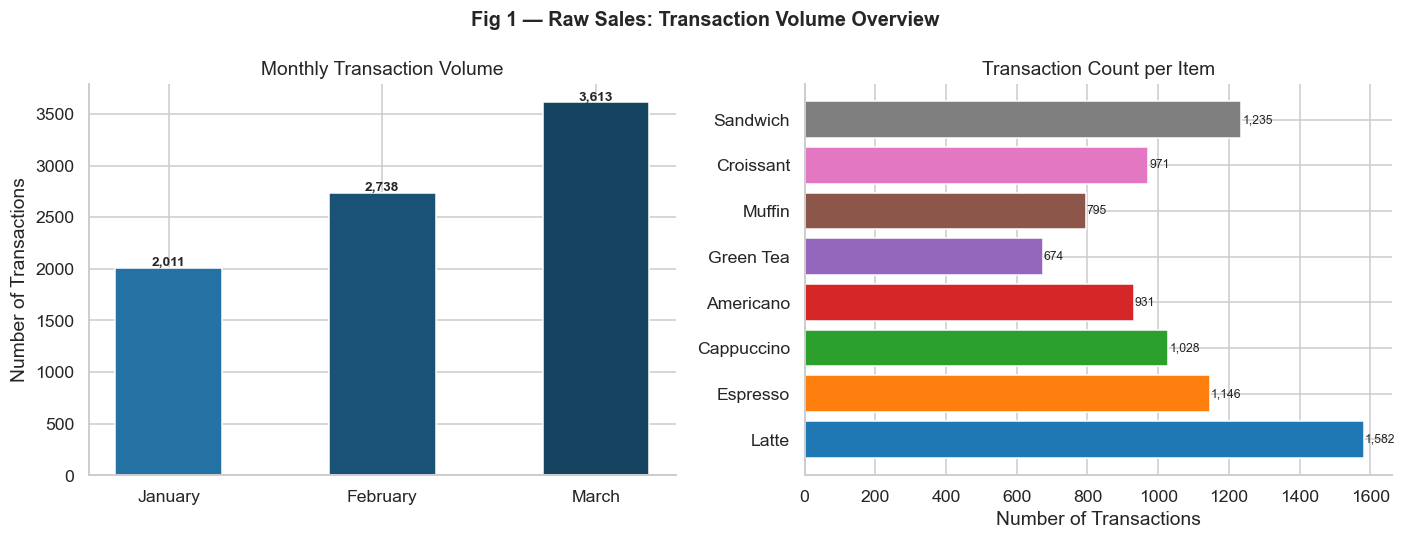

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Monthly transaction count
m_cnt = raw.groupby("month")["transaction_id"].count().reindex(MONTH_ORDER)
colors_m = ["#2471a3", "#1a5276", "#154360"]
bars = axes[0].bar(MONTH_ORDER, m_cnt.values, color=colors_m, width=0.5, edgecolor="white")
axes[0].set_title("Monthly Transaction Volume")
axes[0].set_ylabel("Number of Transactions")
for bar, v in zip(bars, m_cnt.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 15,
                 f"{v:,}", ha="center", fontsize=9, fontweight="bold")

# Per-item transaction count (horizontal bar)
i_cnt = raw.groupby("item_name")["transaction_id"].count().reindex(ITEM_ORDER)
hbars = axes[1].barh(range(len(ITEM_ORDER)), i_cnt.values,
                     color=[ITEM_COLOR[it] for it in ITEM_ORDER])
axes[1].set_yticks(range(len(ITEM_ORDER)))
axes[1].set_yticklabels(ITEM_ORDER)
axes[1].set_title("Transaction Count per Item")
axes[1].set_xlabel("Number of Transactions")
for i, v in enumerate(i_cnt.values):
    axes[1].text(v + 3, i, f"{v:,}", va="center", fontsize=8)

fig.suptitle("Fig 1 — Raw Sales: Transaction Volume Overview",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


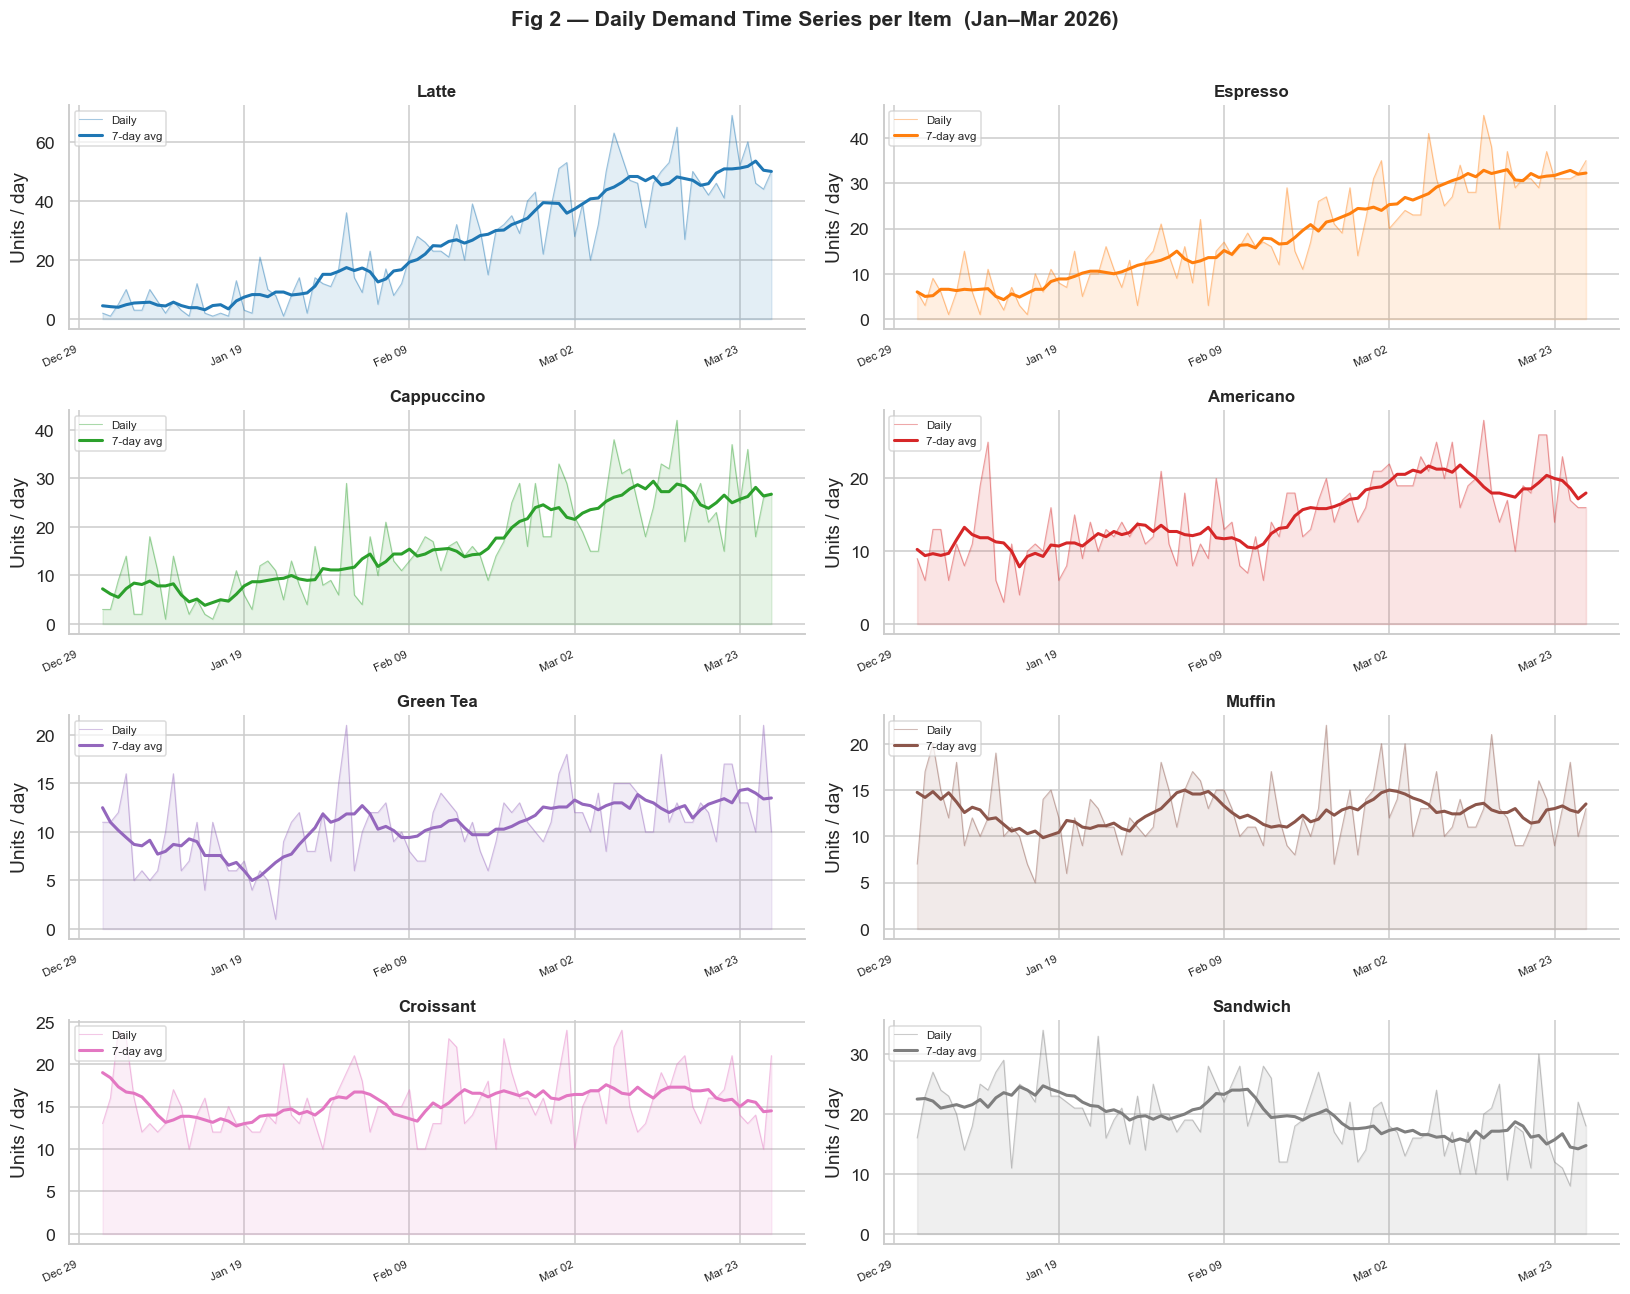

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, item in enumerate(ITEM_ORDER):
    ax    = axes[idx]
    color = ITEM_COLOR[item]
    d     = demand[demand["item_name"] == item].sort_values("date")
    roll7 = d["daily_demand"].rolling(7, center=True, min_periods=4).mean()

    ax.fill_between(d["date"], d["daily_demand"], alpha=0.12, color=color)
    ax.plot(d["date"], d["daily_demand"], color=color, alpha=0.4, lw=0.7, label="Daily")
    ax.plot(d["date"], roll7,             color=color, lw=2.0,          label="7-day avg")

    ax.set_title(item, fontsize=11, fontweight="bold")
    ax.set_ylabel("Units / day")
    ax.legend(fontsize=7.5, loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right", fontsize=7.5)

fig.suptitle("Fig 2 — Daily Demand Time Series per Item  (Jan–Mar 2026)",
             fontweight="bold", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


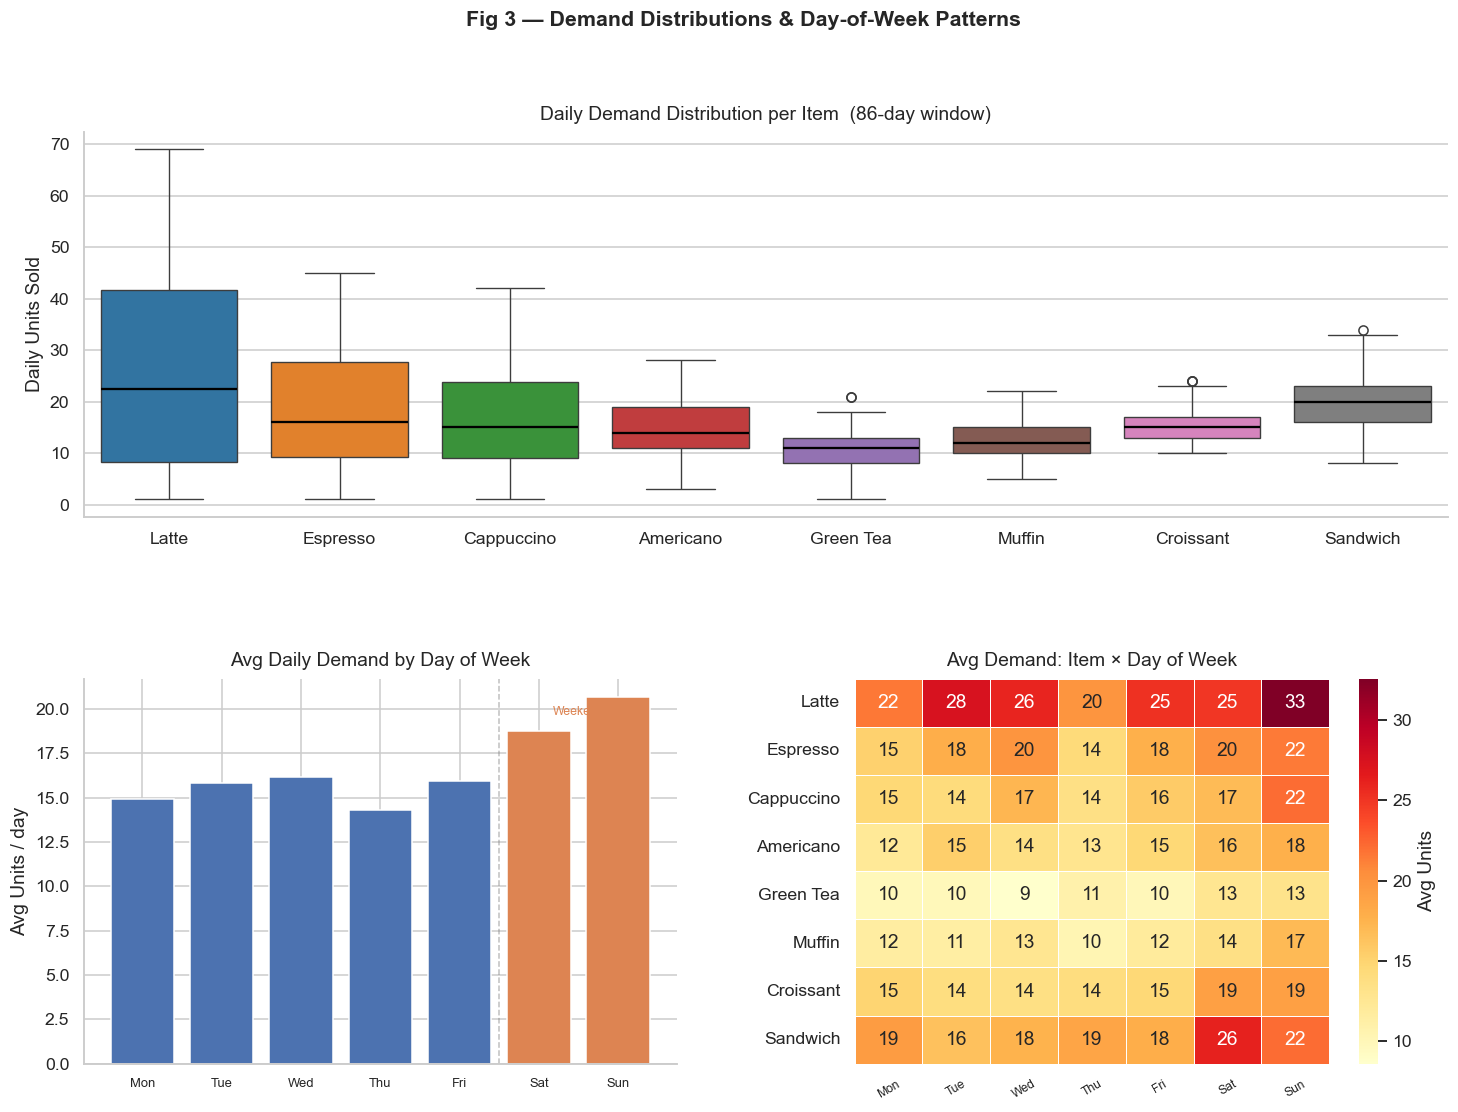

In [5]:
fig = plt.figure(figsize=(16, 11))
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.3)

# Box plots (full width)
ax1 = fig.add_subplot(gs[0, :])
demand_cat = demand.copy()
demand_cat["item_name"] = pd.Categorical(demand_cat["item_name"],
                                          categories=ITEM_ORDER, ordered=True)
sns.boxplot(data=demand_cat.sort_values("item_name"),
            x="item_name", y="daily_demand",
            palette=PALETTE, ax=ax1, linewidth=0.9,
            medianprops={"color": "black", "lw": 1.5})
ax1.set_xlabel("")
ax1.set_ylabel("Daily Units Sold")
ax1.set_title("Daily Demand Distribution per Item  (86-day window)", pad=8)

# Day-of-week bar chart
ax2 = fig.add_subplot(gs[1, 0])
dow_avg    = demand.groupby("day_of_week")["daily_demand"].mean().reindex(DOW_ORDER)
bar_colors = ["#4c72b0"] * 5 + ["#dd8452"] * 2
ax2.bar(range(7), dow_avg.values, color=bar_colors, edgecolor="white")
ax2.set_xticks(range(7))
ax2.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], fontsize=8.5)
ax2.set_ylabel("Avg Units / day")
ax2.set_title("Avg Daily Demand by Day of Week", pad=8)
ax2.axvline(4.5, color="gray", linestyle="--", lw=1, alpha=0.5)
ax2.text(5.5, dow_avg.max() * 0.95, "Weekend", ha="center", fontsize=8, color="#dd8452")

# Item × day-of-week heatmap
ax3 = fig.add_subplot(gs[1, 1])
hmap_data = (demand.groupby(["item_name", "day_of_week"])["daily_demand"]
                   .mean()
                   .unstack("day_of_week")
                   .reindex(columns=DOW_ORDER)
                   .reindex(ITEM_ORDER))
sns.heatmap(hmap_data, ax=ax3, cmap="YlOrRd",
            annot=True, fmt=".0f", linewidths=0.4,
            cbar_kws={"label": "Avg Units"})
ax3.set_title("Avg Demand: Item × Day of Week", pad=8)
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=30, fontsize=8)

fig.suptitle("Fig 3 — Demand Distributions & Day-of-Week Patterns",
             fontweight="bold", fontsize=14)
plt.show()


---
## §2  Weather Data — Exploratory Analysis


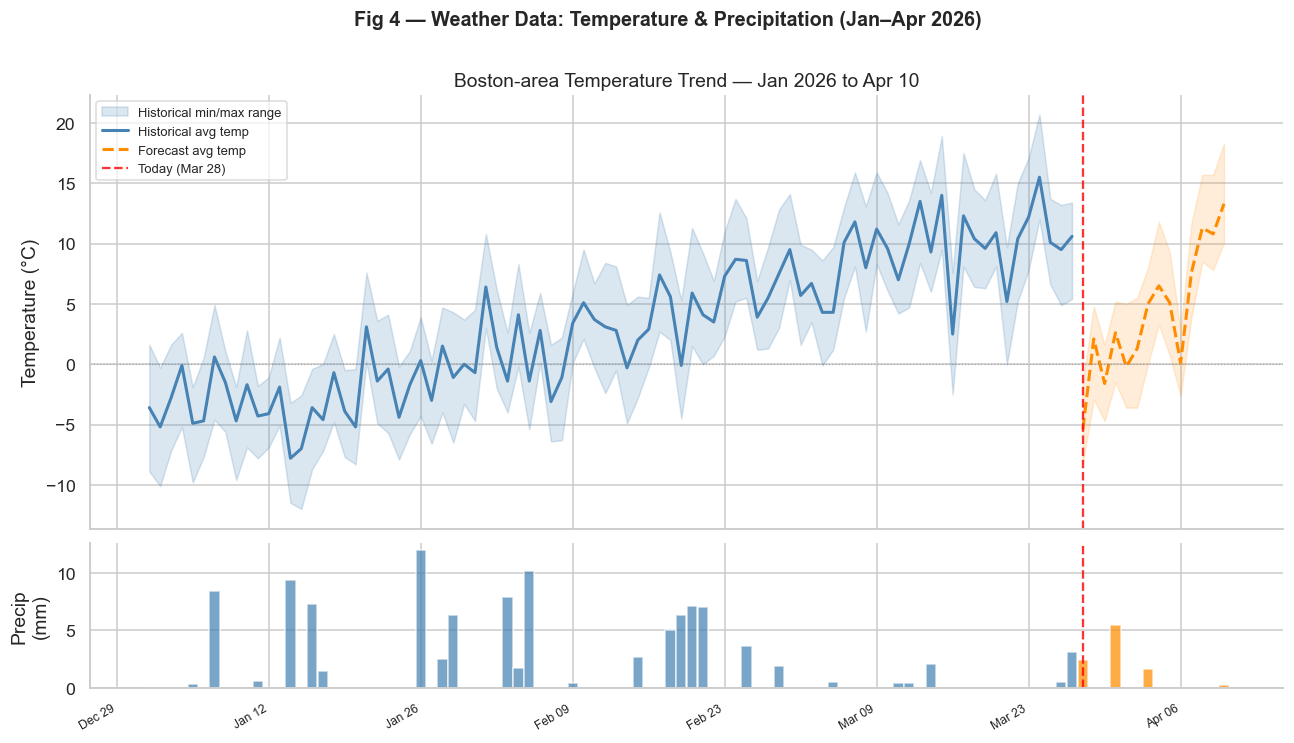

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

cutoff = pd.Timestamp("2026-03-28")

# Temperature: historical band + line
ax1.fill_between(hist_w["date"], hist_w["temp_min"], hist_w["temp_max"],
                 alpha=0.20, color="steelblue", label="Historical min/max range")
ax1.plot(hist_w["date"], hist_w["temp_avg"],
         color="steelblue", lw=2.0, label="Historical avg temp")

# Temperature: forecast band + line
ax1.fill_between(fcast_w["date"], fcast_w["temp_min"], fcast_w["temp_max"],
                 alpha=0.15, color="darkorange")
ax1.plot(fcast_w["date"], fcast_w["temp_avg"],
         "--", color="darkorange", lw=2.0, label="Forecast avg temp")

ax1.axhline(0, color="gray", lw=0.8, linestyle=":", alpha=0.6)
ax1.axvline(cutoff, color="red", lw=1.5, linestyle="--", alpha=0.8, label="Today (Mar 28)")
ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Boston-area Temperature Trend — Jan 2026 to Apr 10")
ax1.legend(fontsize=8.5, loc="upper left")

# Precipitation bars
bar_clrs = ["darkorange" if d >= cutoff else "steelblue" for d in weather["date"]]
ax2.bar(weather["date"], weather["precipitation"], color=bar_clrs, alpha=0.72, width=0.95)
ax2.axvline(cutoff, color="red", lw=1.5, linestyle="--", alpha=0.8)
ax2.set_ylabel("Precip\n(mm)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

fig.suptitle("Fig 4 — Weather Data: Temperature & Precipitation (Jan–Apr 2026)",
             fontweight="bold", fontsize=13, y=0.99)
plt.show()


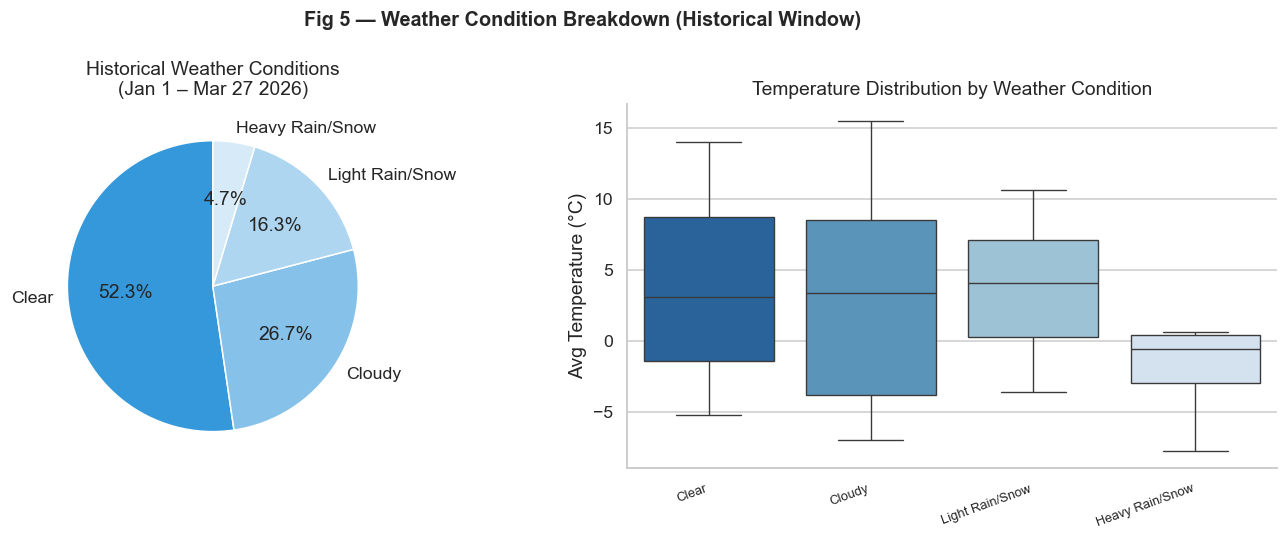

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart: condition counts (historical)
cond_counts = hist_w["condition"].value_counts()
wedge_colors = ["#3498db", "#85c1e9", "#aed6f1", "#d6eaf8"][:len(cond_counts)]
axes[0].pie(cond_counts.values,
            labels=cond_counts.index,
            autopct="%1.1f%%",
            colors=wedge_colors,
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1})
axes[0].set_title("Historical Weather Conditions\n(Jan 1 – Mar 27 2026)")

# Box: temperature distribution by condition
cond_order = cond_counts.index.tolist()
sns.boxplot(data=hist_w, x="condition", y="temp_avg",
            palette="Blues_r", ax=axes[1], order=cond_order, linewidth=0.9)
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg Temperature (°C)")
axes[1].set_title("Temperature Distribution by Weather Condition")
plt.setp(axes[1].xaxis.get_ticklabels(), rotation=20, ha="right", fontsize=8.5)

fig.suptitle("Fig 5 — Weather Condition Breakdown (Historical Window)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


---
## §3  Sales–Weather Relationship


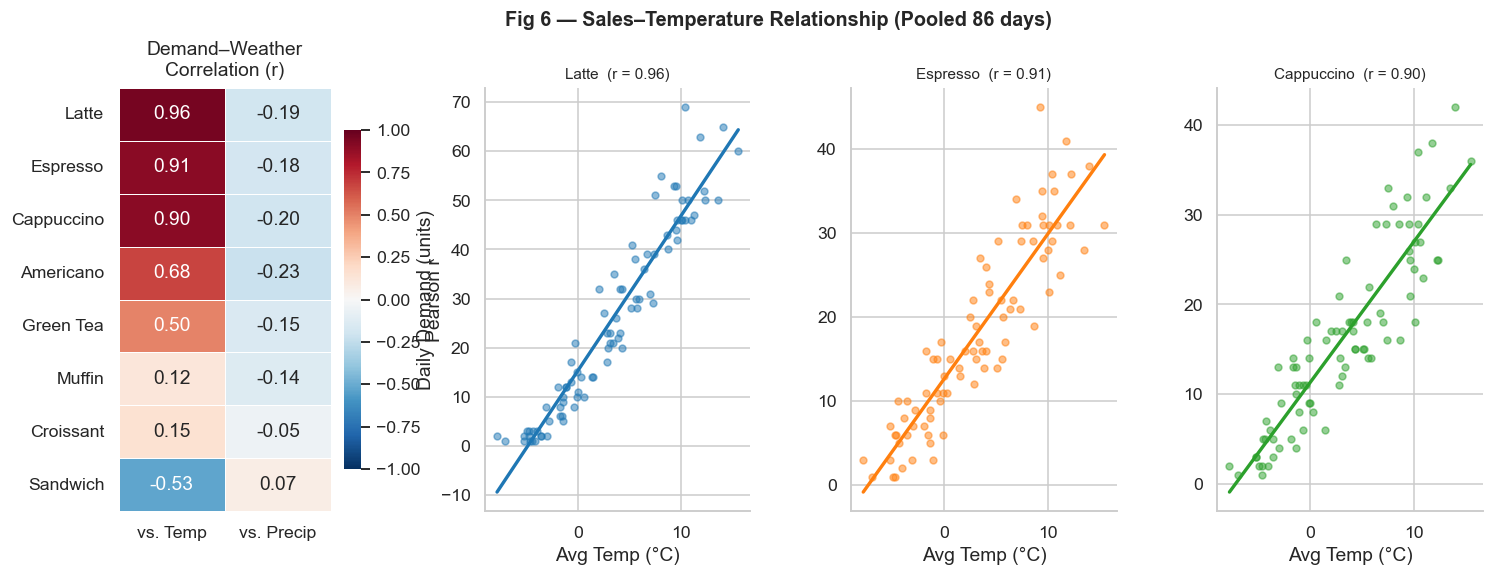

In [8]:
fig = plt.figure(figsize=(16, 5))
gs  = fig.add_gridspec(1, 4, wspace=0.38)

# Per-item Pearson correlation with weather features
ax0 = fig.add_subplot(gs[0, 0])
corr_data = {}
for item in ITEM_ORDER:
    d = modeling[modeling["item_name"] == item]
    corr_data[item] = {
        "vs. Temp":   round(d["daily_demand"].corr(d["temp_avg"]),       3),
        "vs. Precip": round(d["daily_demand"].corr(d["precipitation"]),  3),
    }
corr_df = pd.DataFrame(corr_data).T
sns.heatmap(corr_df, ax=ax0, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"label": "Pearson r", "shrink": 0.8})
ax0.set_title("Demand–Weather\nCorrelation (r)", pad=8)
ax0.set_ylabel("")

# Scatter: demand vs avg temperature — top 3 drink items
for i, item in enumerate(["Latte", "Espresso", "Cappuccino"]):
    ax    = fig.add_subplot(gs[0, i + 1])
    color = ITEM_COLOR[item]
    d     = modeling[modeling["item_name"] == item]
    ax.scatter(d["temp_avg"], d["daily_demand"], color=color, alpha=0.50, s=20)
    z      = np.polyfit(d["temp_avg"], d["daily_demand"], 1)
    x_line = np.linspace(d["temp_avg"].min(), d["temp_avg"].max(), 60)
    ax.plot(x_line, np.poly1d(z)(x_line), color=color, lw=2.2)
    r = d[["temp_avg", "daily_demand"]].corr().iloc[0, 1]
    ax.set_title(f"{item}  (r = {r:.2f})", fontsize=10)
    ax.set_xlabel("Avg Temp (°C)")
    if i == 0:
        ax.set_ylabel("Daily Demand (units)")

fig.suptitle("Fig 6 — Sales–Temperature Relationship (Pooled 86 days)",
             fontweight="bold", fontsize=13, y=1.02)
plt.show()


---
## §4  Model Performance — Step 5 Outcomes

Prophet was trained per item in two variants:
- **Baseline** — weekly seasonality only
- **Weather-augmented** — weekly seasonality + `temp_avg` + `precipitation` as regressors

In-sample MAE and RMSE are compared below.


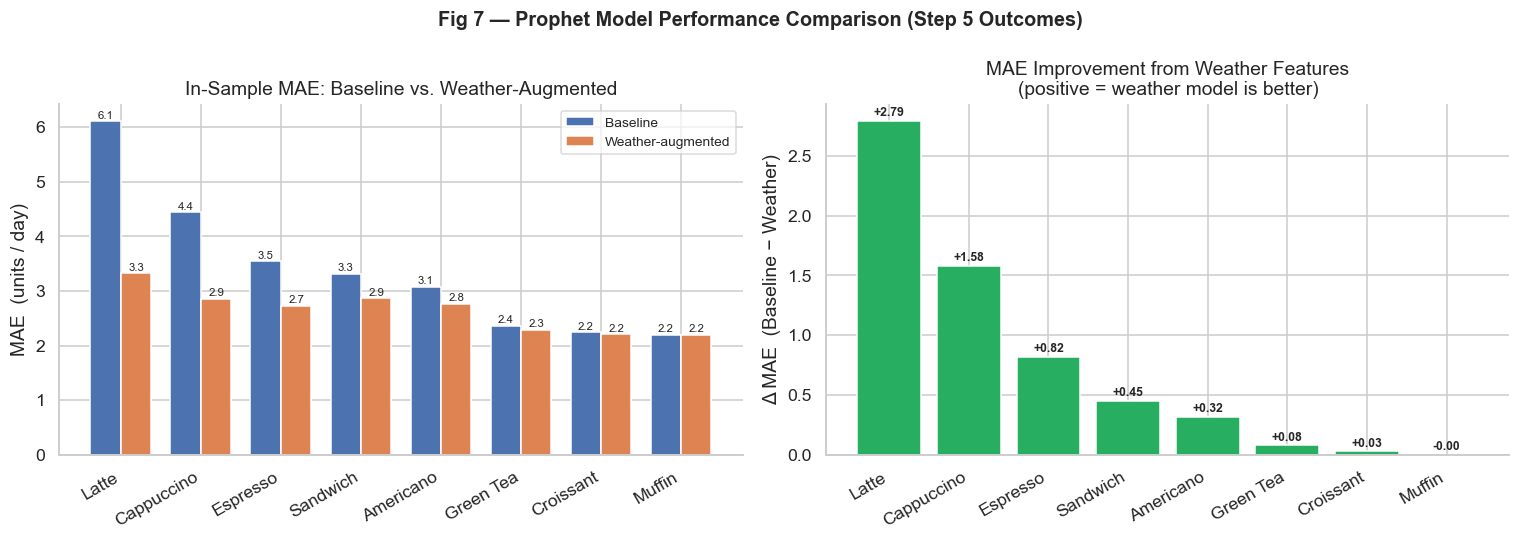

In [9]:
res = results.sort_values("delta_mae", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar: MAE baseline vs weather
x = np.arange(len(res))
w = 0.38
b1 = axes[0].bar(x - w/2, res["mae_baseline"], w,
                 label="Baseline", color="#4c72b0", edgecolor="white")
b2 = axes[0].bar(x + w/2, res["mae_weather"],  w,
                 label="Weather-augmented", color="#dd8452", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(res["item_name"], rotation=30, ha="right")
axes[0].set_ylabel("MAE  (units / day)")
axes[0].set_title("In-Sample MAE: Baseline vs. Weather-Augmented")
axes[0].legend(fontsize=9)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.05,
                 f"{h:.1f}", ha="center", fontsize=7.5)

# Delta MAE bar
bar_c = ["#27ae60" if v > 0 else "#e74c3c" for v in res["delta_mae"]]
bars2 = axes[1].bar(res["item_name"], res["delta_mae"], color=bar_c, edgecolor="white")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticklabels(res["item_name"], rotation=30, ha="right")
axes[1].set_ylabel("Δ MAE  (Baseline − Weather)")
axes[1].set_title("MAE Improvement from Weather Features\n(positive = weather model is better)")
for bar, v in zip(bars2, res["delta_mae"]):
    ypos = v + 0.04 if v >= 0 else v - 0.20
    axes[1].text(bar.get_x() + bar.get_width()/2, ypos,
                 f"{v:+.2f}", ha="center", fontsize=8, fontweight="bold")

fig.suptitle("Fig 7 — Prophet Model Performance Comparison (Step 5 Outcomes)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


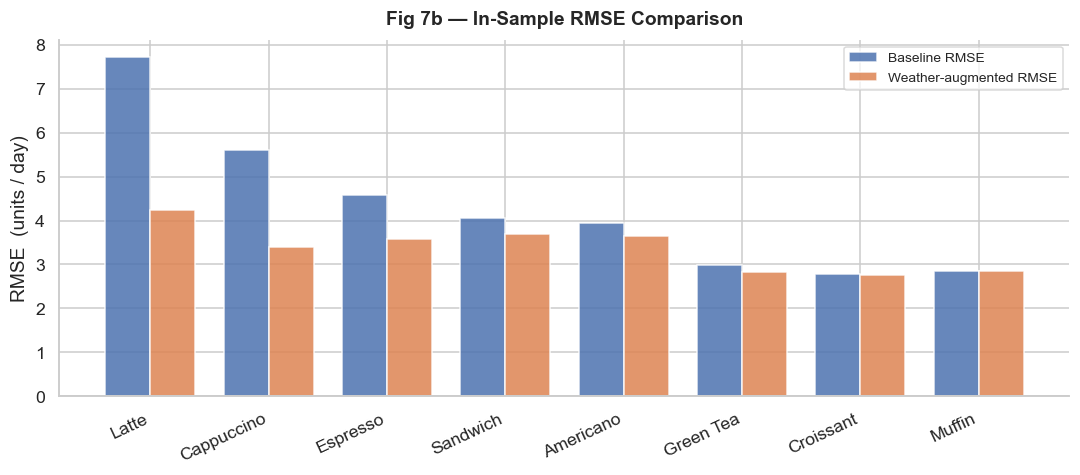

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))

x = np.arange(len(res))
w = 0.38
ax.bar(x - w/2, res["rmse_baseline"], w, label="Baseline RMSE",           color="#4c72b0", alpha=0.85)
ax.bar(x + w/2, res["rmse_weather"],  w, label="Weather-augmented RMSE",  color="#dd8452", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(res["item_name"], rotation=25, ha="right")
ax.set_ylabel("RMSE  (units / day)")
ax.set_title("Fig 7b — In-Sample RMSE Comparison", fontweight="bold", pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## §5  Demand Forecasts — Step 6 Outcomes

Each subplot shows 86 days of historical demand (grey) overlaid with the fitted 7-day rolling average,
then the 14-day out-of-sample forecast from both model variants.
The red dotted line marks the forecast start (2026-03-28).


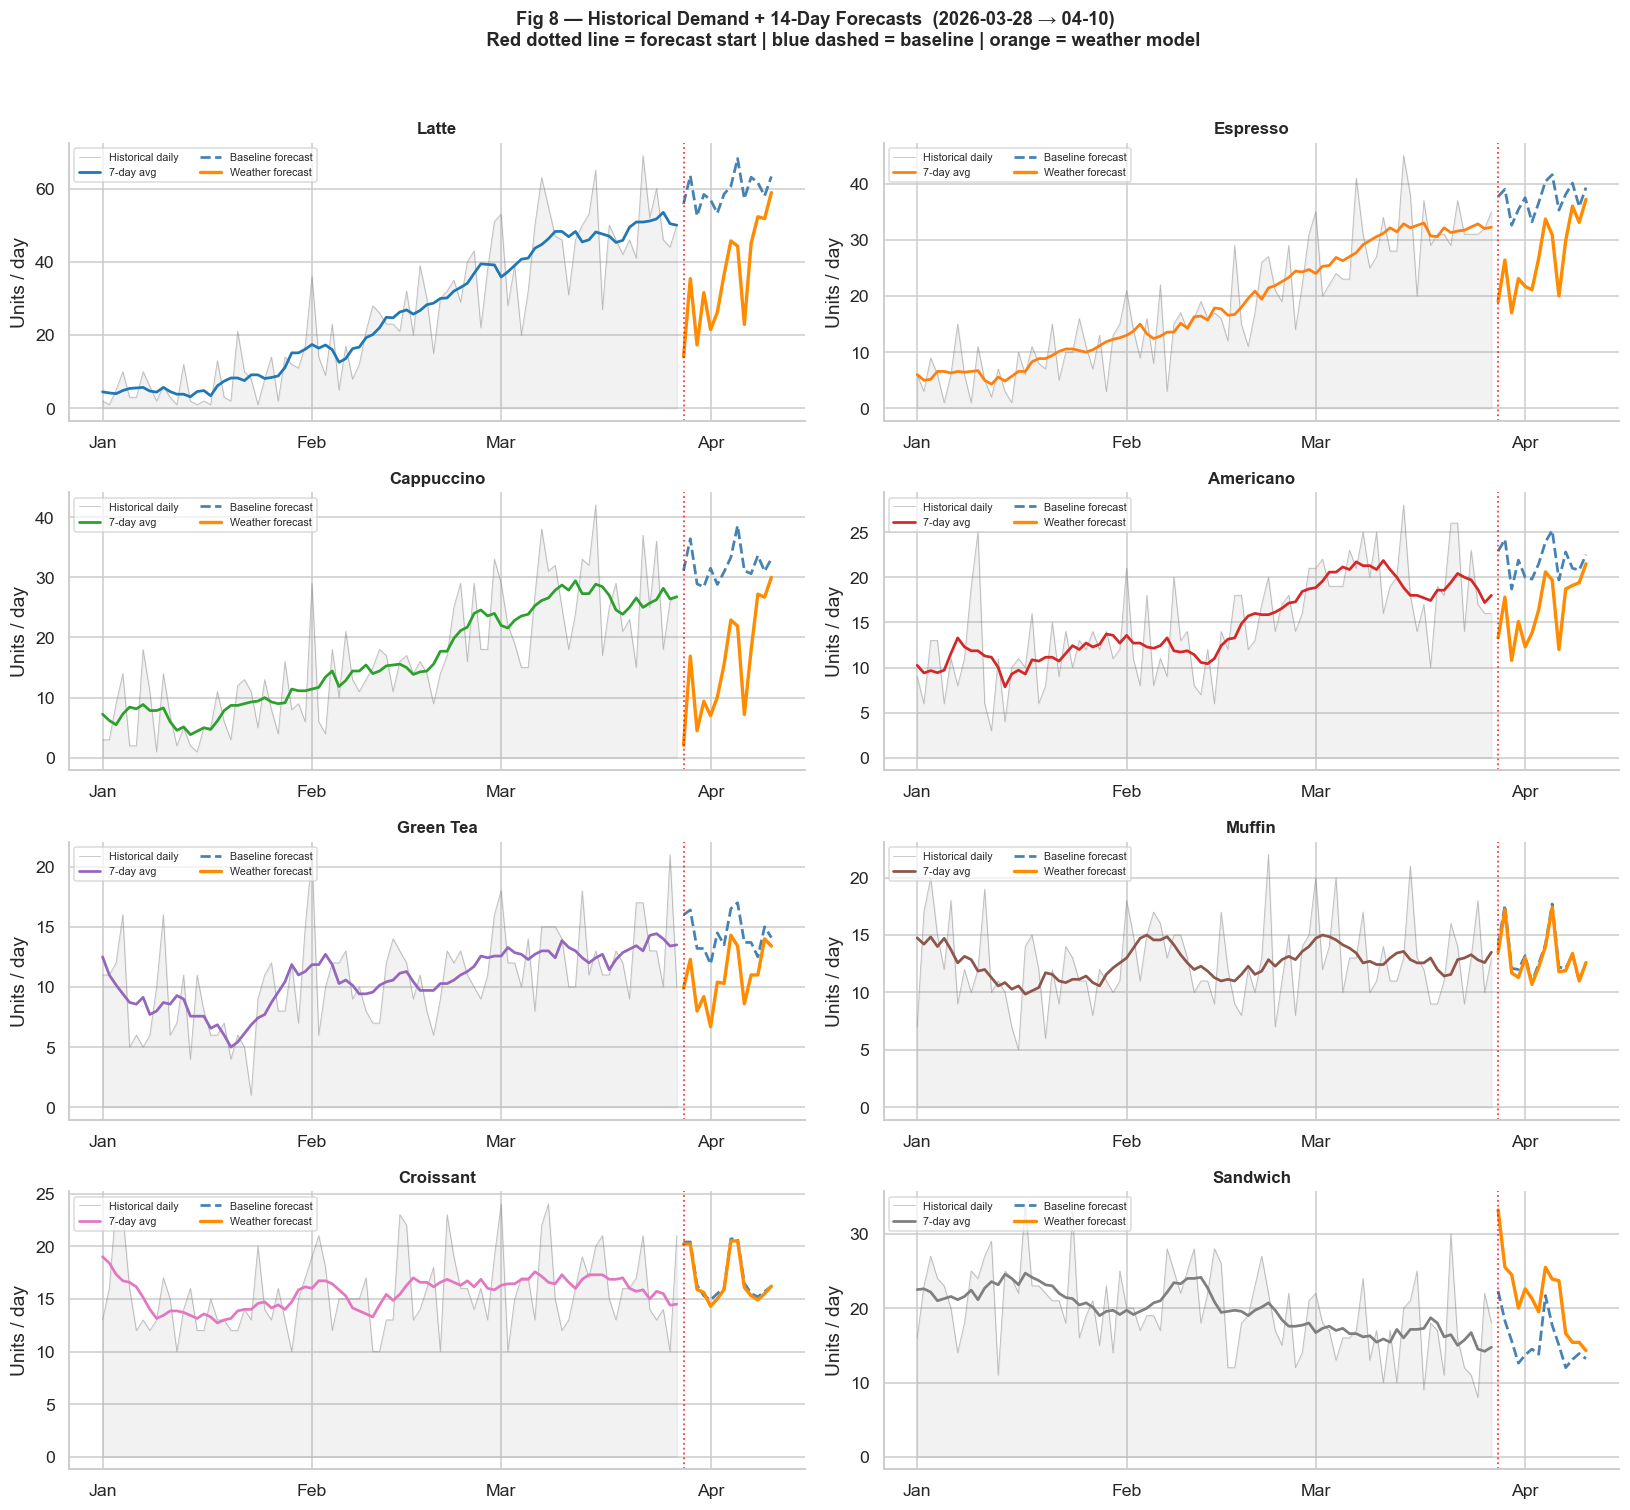

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(15, 14))
axes = axes.flatten()

for idx, item in enumerate(ITEM_ORDER):
    ax         = axes[idx]
    color      = ITEM_COLOR[item]
    hist_item  = modeling[modeling["item_name"] == item].sort_values("date")
    fcast_item = forecasts[forecasts["item_name"] == item].sort_values("date")
    roll7      = hist_item["daily_demand"].rolling(7, center=True, min_periods=4).mean()

    # Historical raw + smoothed
    ax.fill_between(hist_item["date"], hist_item["daily_demand"],
                    alpha=0.10, color="gray")
    ax.plot(hist_item["date"], hist_item["daily_demand"],
            color="gray", lw=0.6, alpha=0.45, label="Historical daily")
    ax.plot(hist_item["date"], roll7, color=color, lw=1.8, label="7-day avg")

    # Forecasts
    ax.plot(fcast_item["date"], fcast_item["forecast_baseline"],
            "--", color="steelblue", lw=1.8, label="Baseline forecast")
    ax.plot(fcast_item["date"], fcast_item["forecast_weather"],
            "-",  color="darkorange", lw=2.2, label="Weather forecast")

    # Forecast boundary
    ax.axvline(FCAST_START, color="red", lw=1.2, linestyle=":", alpha=0.75)
    ax.set_title(item, fontsize=11, fontweight="bold")
    ax.set_ylabel("Units / day")
    ax.legend(fontsize=7, loc="upper left", ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

fig.suptitle(
    "Fig 8 — Historical Demand + 14-Day Forecasts  (2026-03-28 → 04-10)"
    "\n           Red dotted line = forecast start | blue dashed = baseline | orange = weather model",
    fontweight="bold", fontsize=12
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


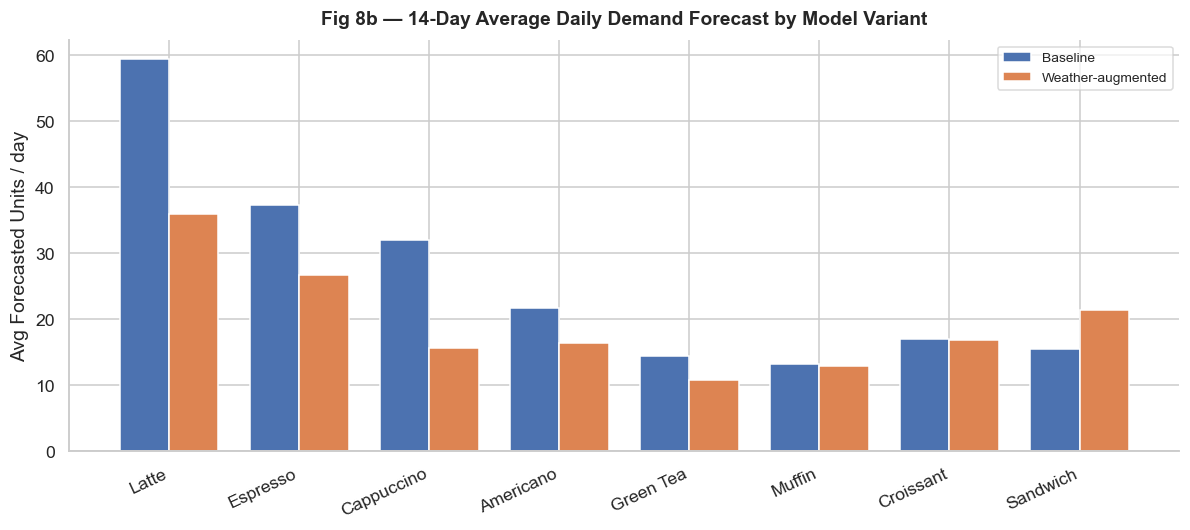


14-Day Forecast Summary Table:
 item_name  forecast_baseline  forecast_weather
     Latte               59.4              36.0
  Espresso               37.3              26.8
Cappuccino               32.0              15.7
 Americano               21.8              16.5
 Green Tea               14.4              10.9
    Muffin               13.2              13.0
 Croissant               17.1              16.9
  Sandwich               15.5              21.5


In [12]:
# Average daily forecast by item and model variant
fcast_summary = (
    forecasts
    .groupby("item_name")[["forecast_baseline", "forecast_weather"]]
    .mean()
    .round(1)
    .reindex(ITEM_ORDER)
    .reset_index()
)

x = np.arange(len(fcast_summary))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, fcast_summary["forecast_baseline"], w,
       label="Baseline",           color="#4c72b0", edgecolor="white")
ax.bar(x + w/2, fcast_summary["forecast_weather"],  w,
       label="Weather-augmented",  color="#dd8452", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(fcast_summary["item_name"], rotation=25, ha="right")
ax.set_ylabel("Avg Forecasted Units / day")
ax.set_title("Fig 8b — 14-Day Average Daily Demand Forecast by Model Variant",
             fontweight="bold", pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n14-Day Forecast Summary Table:")
print(fcast_summary.to_string(index=False))


---
## §6  Stock-Out Risk — Step 6 Outcomes

The left panel ranks items by estimated days until stock-out (weather model forecast).
Items in **red** reach zero within 7 days; **orange** within 14 days.
The right panel shows the cumulative inventory depletion curve for at-risk items.


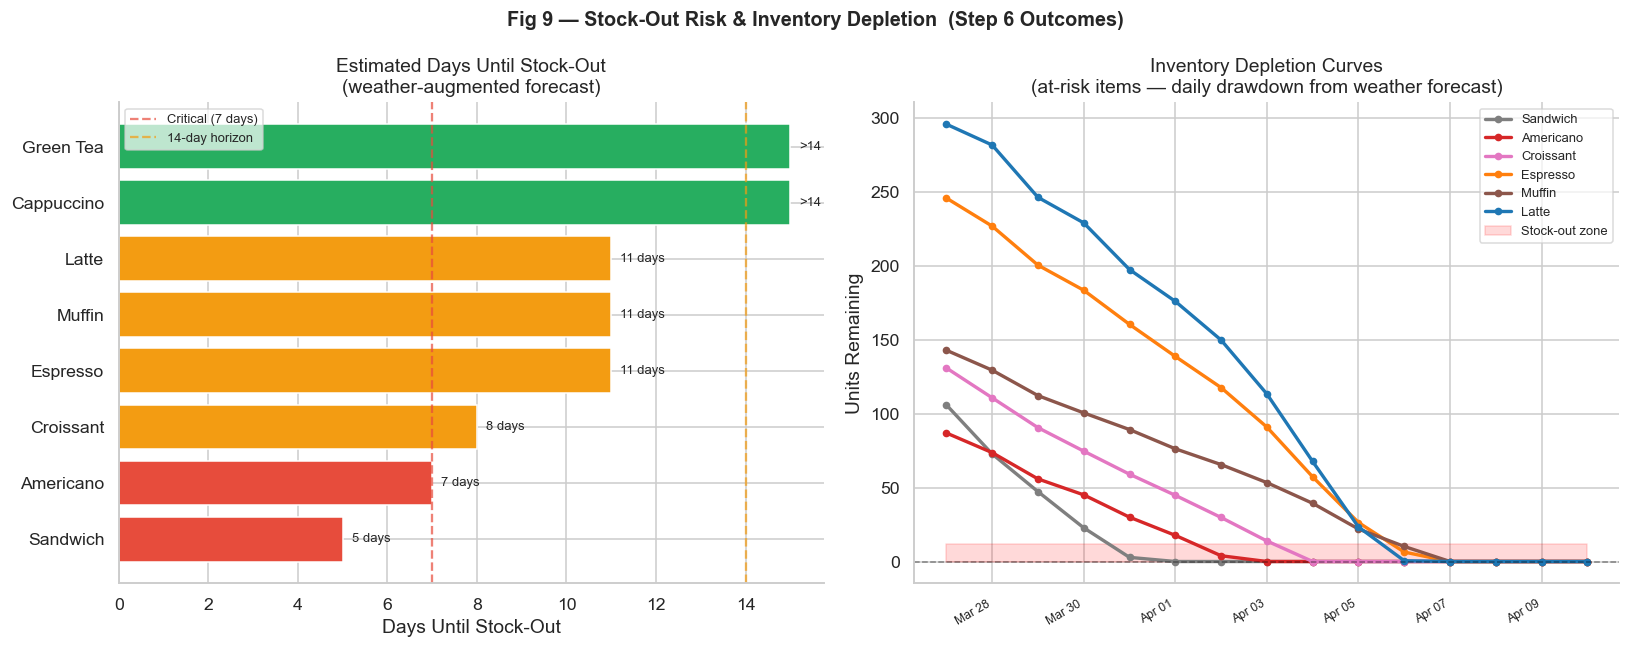

In [13]:
def parse_days(v):
    try:
        return float(v)
    except Exception:
        return 15.0

stockout_s = stockout.copy()
stockout_s["days_num"] = stockout_s["days_until_stockout"].apply(parse_days)
stockout_s = stockout_s.sort_values("days_num").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Horizontal bar: days until stock-out ---
bar_c = ["#e74c3c" if d <= 7 else "#f39c12" if d <= 11 else "#27ae60"
         for d in stockout_s["days_num"]]
hbars = axes[0].barh(stockout_s["item_name"], stockout_s["days_num"],
                     color=bar_c, edgecolor="white")
axes[0].axvline(7,  color="#e74c3c", lw=1.5, linestyle="--", alpha=0.7, label="Critical (7 days)")
axes[0].axvline(14, color="#f39c12", lw=1.5, linestyle="--", alpha=0.7, label="14-day horizon")
axes[0].set_xlabel("Days Until Stock-Out")
axes[0].set_title("Estimated Days Until Stock-Out\n(weather-augmented forecast)")
axes[0].legend(fontsize=8.5)
for bar, orig_val in zip(hbars, stockout_s["days_until_stockout"]):
    label = f">{14}" if str(orig_val).startswith(">") else f"{int(bar.get_width())} days"
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 label, va="center", fontsize=8.5)

# --- Inventory depletion curves ---
at_risk = stockout_s[stockout_s["days_num"] <= 14]["item_name"].tolist()
max_stock = 0

for item in at_risk:
    color     = ITEM_COLOR[item]
    stock_qty = int(stock.loc[stock["item_name"] == item, "current_stock"].iloc[0])
    item_f    = forecasts[forecasts["item_name"] == item].sort_values("date")

    # Build cumulative depletion starting from current stock
    dates_list = [FCAST_START - pd.Timedelta(days=1)]
    remaining  = [stock_qty]
    for _, row in item_f.iterrows():
        remaining.append(max(0.0, remaining[-1] - row["forecast_weather"]))
        dates_list.append(row["date"])

    max_stock = max(max_stock, stock_qty)
    axes[1].plot(dates_list, remaining, color=color, lw=2.2,
                 marker="o", markersize=4, label=item)

axes[1].axhline(0, color="black", lw=1, linestyle="--", alpha=0.4)
if max_stock > 0:
    axes[1].fill_between([FCAST_START - pd.Timedelta(days=1), FCAST_END],
                         0, max_stock * 0.04,
                         color="red", alpha=0.15, label="Stock-out zone")
axes[1].set_ylabel("Units Remaining")
axes[1].set_title("Inventory Depletion Curves\n(at-risk items — daily drawdown from weather forecast)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
axes[1].legend(fontsize=8.5)

fig.suptitle("Fig 9 — Stock-Out Risk & Inventory Depletion  (Step 6 Outcomes)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


In [14]:
print("=" * 55)
print("  Stock-Out Risk Summary (weather model, 14-day window)")
print("=" * 55)
print(stockout_s[["item_name", "current_stock", "days_until_stockout"]]
      .rename(columns={"item_name": "Item",
                        "current_stock": "Stock",
                        "days_until_stockout": "Days Until Stockout"})
      .to_string(index=False))


  Stock-Out Risk Summary (weather model, 14-day window)
      Item  Stock Days Until Stockout
  Sandwich    106                   5
 Americano     87                   7
 Croissant    131                   8
  Espresso    246                  11
    Muffin    143                  11
     Latte    296                  11
Cappuccino    258                 >14
 Green Tea    156                 >14
